<a href="https://colab.research.google.com/github/tiendat1806-06/TRITUENHANTAO/blob/main/BTtrenloptuan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

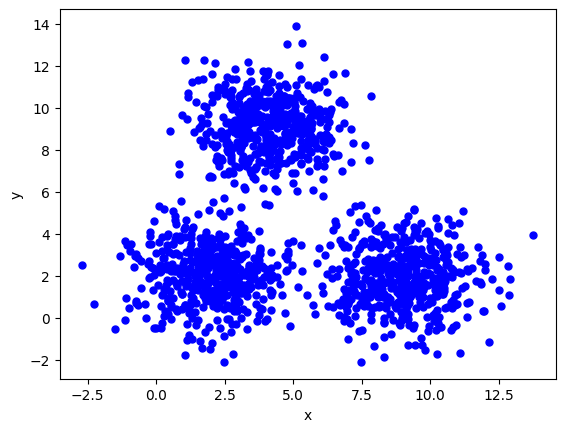

[[8.91145393 0.64545204]
 [9.66392399 4.49558289]
 [4.20317016 9.5022149 ]]


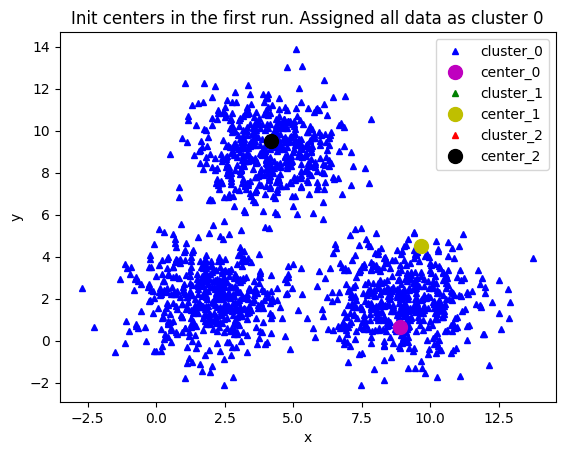

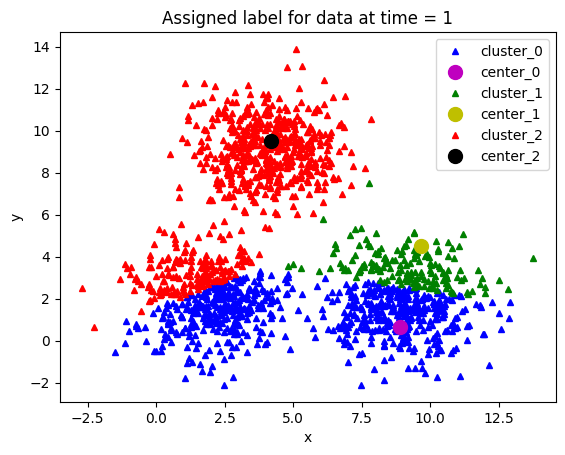

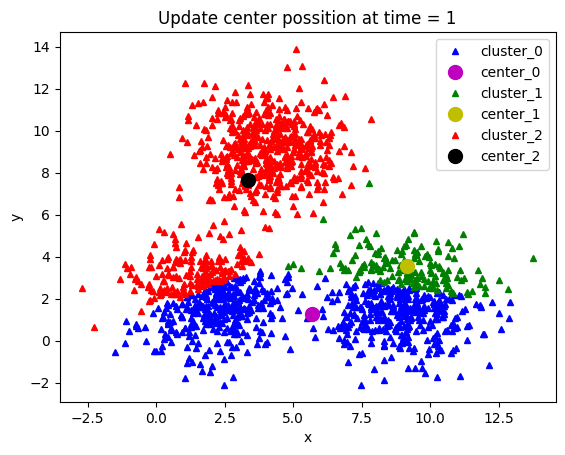

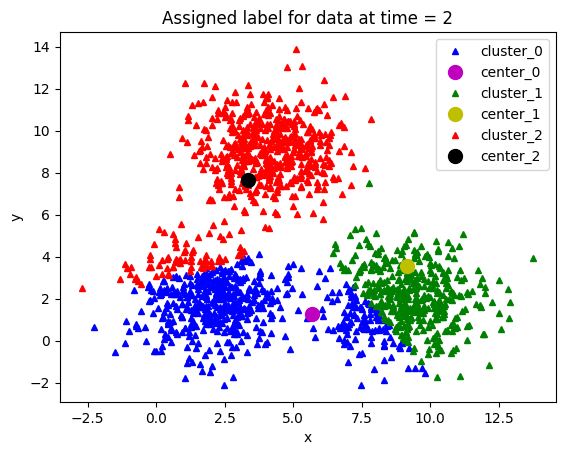

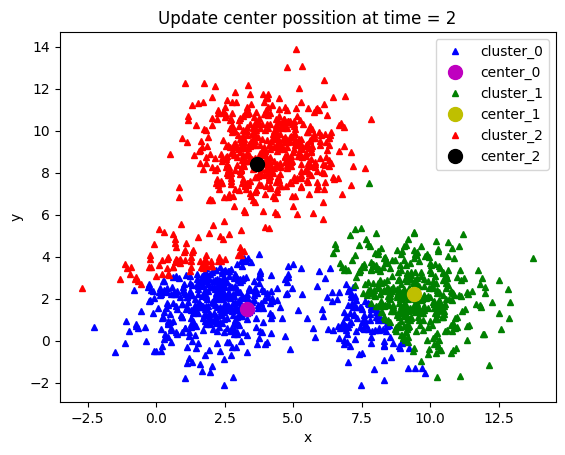

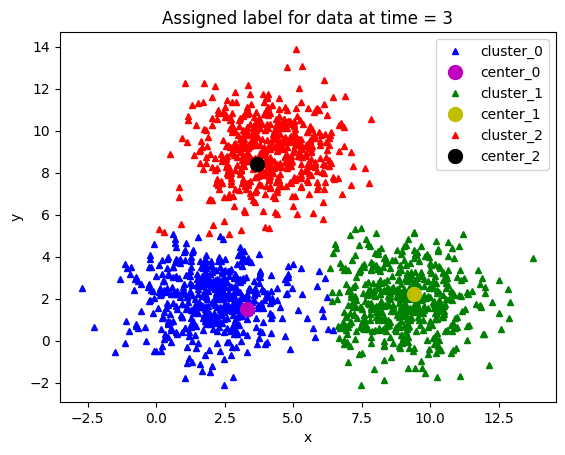

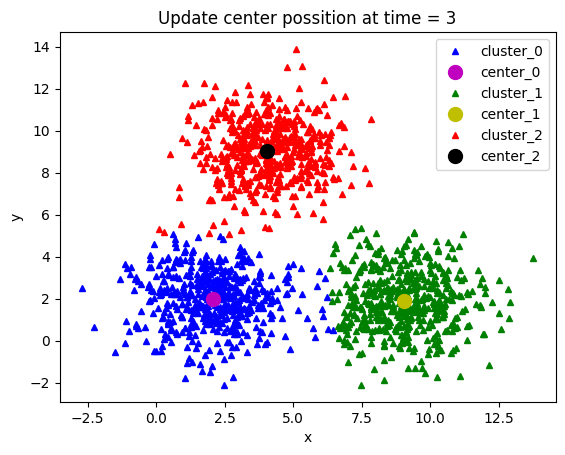

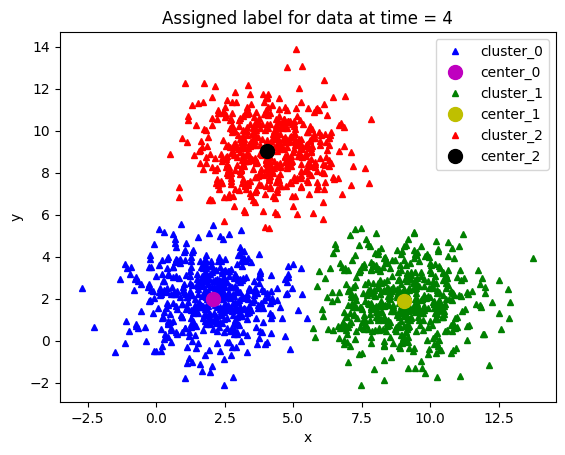

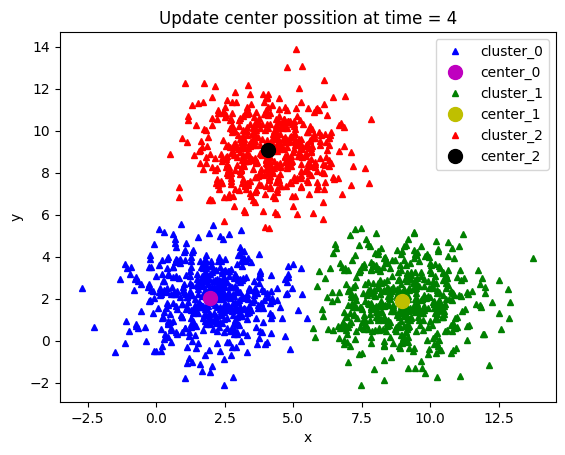

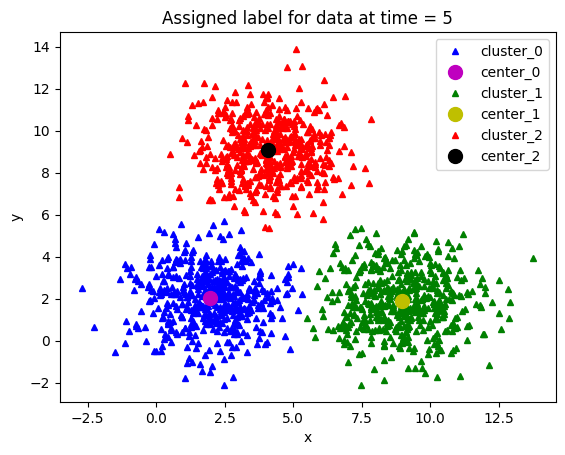

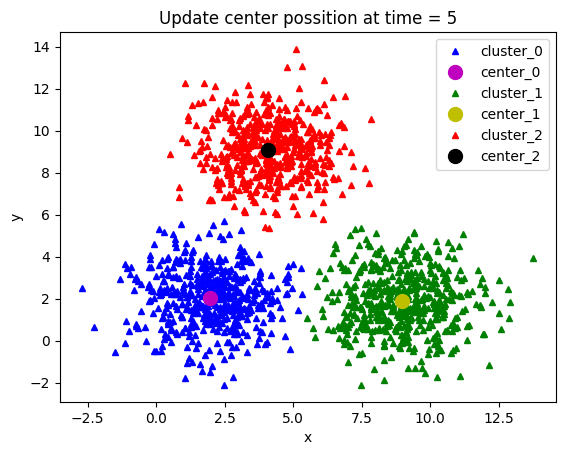

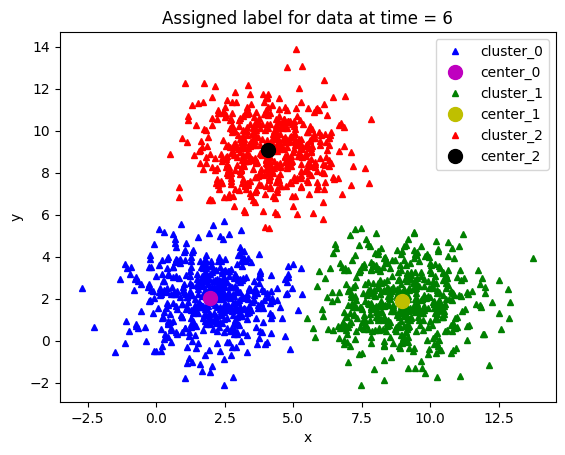

Done! Kmeans has converged after 5 times
[[1.96792384 2.04820137]
 [8.97900721 1.89694495]
 [4.0970963  9.08823785]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.concatenate((X0, X1, X2), axis = 0)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.plot()
plt.show()
def kmeans_init_centers(X, n_cluster):

  return X[np.random.choice(X.shape[0], n_cluster, replace=False)]
def kmeans_predict_labels(X, centers):
  D = cdist(X, centers)
  return np.argmin(D, axis = 1)
def kmeans_update_centers(X, labels, n_cluster):
  centers = np.zeros((n_cluster, X.shape[1]))
  for k in range(n_cluster):
    Xk = X[labels == k, :]
    centers[k,:] = np.mean(Xk, axis = 0)
  return centers
def kmeans_has_converged(centers, new_centers):
  return (set([tuple(a) for a in centers]) ==
      set([tuple(a) for a in new_centers]))

def kmeans_visualize(X, centers, labels, n_cluster, title):
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(title)
  plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

  for i in range(n_cluster):
    data = X[labels == i]
    plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4,
             label='cluster_' + str(i))
    plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10,
             label='center_' + str(i))
  plt.legend()
  plt.show()
def kmeans(init_centes, init_labels, X, n_cluster):
  centers = init_centes
  labels = init_labels
  times = 0
  while True:
    labels = kmeans_predict_labels(X, centers)
    kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))
    new_centers = kmeans_update_centers(X, labels, n_cluster)
    if kmeans_has_converged(centers, new_centers):
      break
    centers = new_centers
    kmeans_visualize(X, centers, labels, n_cluster, 'Update center possition at time = ' + str(times + 1))
    times += 1
  return (centers, labels, times)
init_centers = kmeans_init_centers(X, n_cluster)
print(init_centers)
init_labels = np.zeros(X.shape[0])
kmeans_visualize(X, init_centers, init_labels, n_cluster,
                 'Init centers in the first run. Assigned all data as cluster 0')
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')
print(centers)


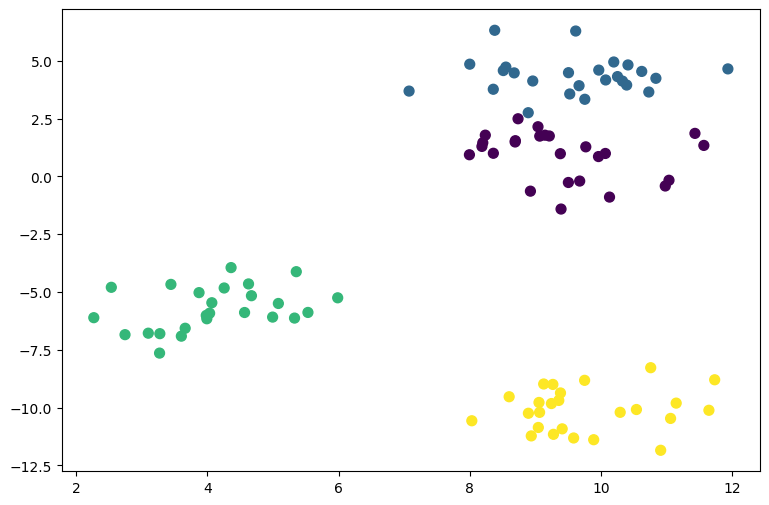

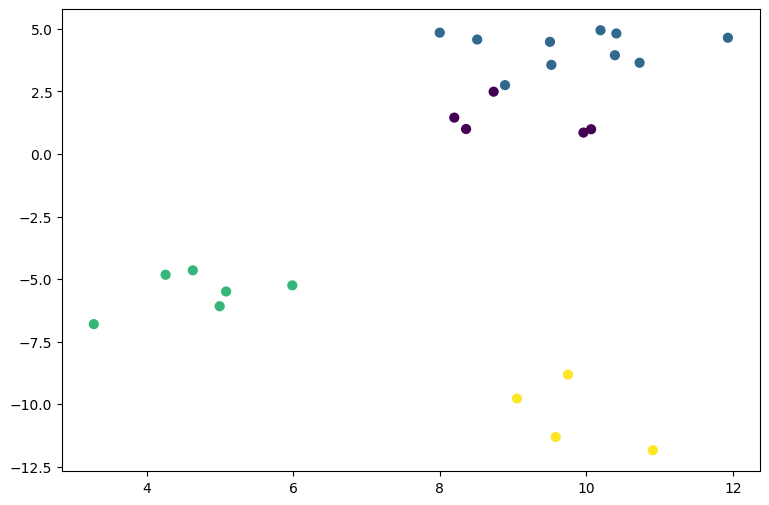

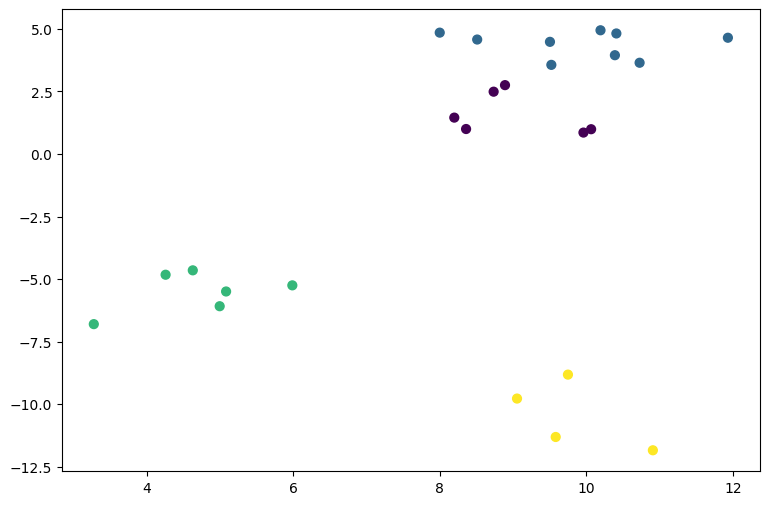

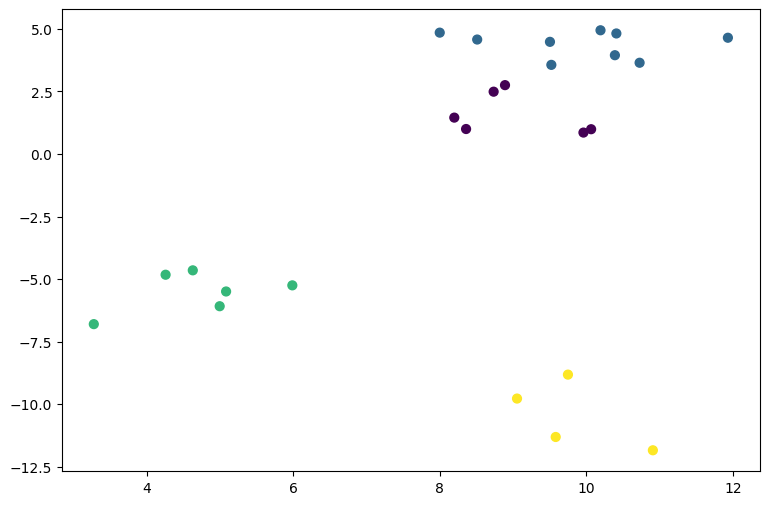

{'n_neighbors': np.int64(2)}
[0]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker= 'o', s=40)
plt.show()
knn5 = KNeighborsClassifier(5)  # k=5
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= 'o', s=40)
plt.show()
knn1 = KNeighborsClassifier(1)  # k=1
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= 'o', s=40)
plt.show()
from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1,10)}, cv=5)
knn_grid.fit(X,y)

print (knn_grid.best_params_)
def KNN(X_train,X_test,y_train,k):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]

    y_pred = np.zeros((num_test,num_train))
    for i in range(num_test):
        for j in range(num_train):
            y_pred[i,j] = np.sqrt(np.sum(np.power(X_test[i,:]-X_train[j,:],2)))
    results = []
    for i in range(len(y_pred)):
        zipped = zip(y_pred[i,:],y_train)
        res = sorted(zipped,key = lambda x:x[0])
        results_topk = res[:k]
        classes = {}
        for _,j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1
        results.append(max(classes,key = classes.get))
    return np.array(results)

(X,y) = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
X_test=np.array([(1,3)])
results = KNN(X,X_test,y,3)
print (results)



--- Kết quả dự đoán cho điểm: [18, 6] ---
[K-Means] Thuật toán dự đoán điểm này thuộc cụm: 1


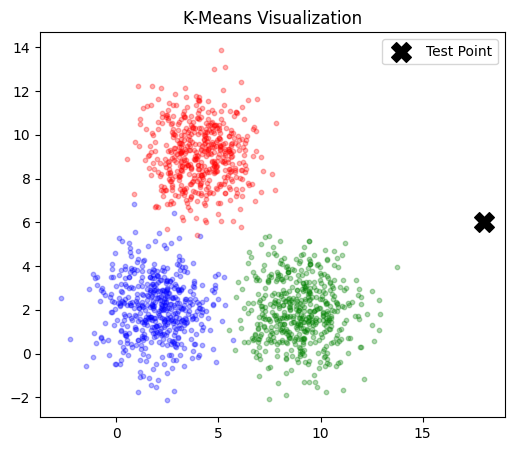

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


thuat_toan = "K-Means" # @param ["K-Means", "KNN"]
x_coord = 18 # @param {type:"number"}
y_coord = 6 # @param {type:"number"}

test_point = np.array([[x_coord, y_coord]])

print(f"--- Kết quả dự đoán cho điểm: [{x_coord}, {y_coord}] ---")

if thuat_toan == "K-Means":
    try:
        distances_to_centers = cdist(test_point, centers)
        closest_cluster = np.argmin(distances_to_centers)
        print(f"[K-Means] Thuật toán dự đoán điểm này thuộc cụm: {closest_cluster}")

        plt.figure(figsize=(6, 5))
        plt.scatter(X0[:, 0], X0[:, 1], c='blue', alpha=0.3, s=10)
        plt.scatter(X1[:, 0], X1[:, 1], c='green', alpha=0.3, s=10)
        plt.scatter(X2[:, 0], X2[:, 1], c='red', alpha=0.3, s=10)
        plt.scatter(test_point[:, 0], test_point[:, 1], c='black', marker='X', s=200, label='Test Point')
        plt.title("K-Means Visualization")
        plt.legend()
        plt.show()
    except NameError:
        print("[Lỗi] Vui lòng chạy ô K-Means ở trên trước.")

else: # KNN
    try:
        knn_label = KNN(X, test_point, y, k=3)
        print(f"[KNN] Thuật toán dự đoán nhãn lớp (Class): {knn_label[0]}")

        plt.figure(figsize=(6, 5))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', alpha=0.5, s=10)
        plt.scatter(test_point[:, 0], test_point[:, 1], c='red', marker='X', s=200, label='Test Point')
        plt.title("KNN Visualization")
        plt.legend()
        plt.show()
    except NameError:
        print("[Lỗi] Vui lòng chạy ô KNN ở trên trước.")